# АНАЛИЗ БРЕНДОВ И ВКУСОВ ПО ТЕКСТАМ ЗАПРОСОВ

In [446]:
import pandas as pd
import json

data = pd.read_json("characteristics.json").set_index("id").sort_index()
df = pd.read_csv("samokat_esci.csv")

# склеиваем запросы с найденной в них информацией
unique_df = df.drop_duplicates(subset=["query"]).reset_index(drop=True)
texts = unique_df["query"].tolist()
unique_reset_id = pd.DataFrame(texts, columns=["text"], index=range(len(texts)))

data_with_query = pd.concat([data, unique_reset_id], axis=1, join='outer')
data_with_query = data_with_query.replace("", value=None)

data_with_query.to_csv("chars+query.csv")


In [447]:
data_with_query.head()

,brands,flavors,characteristics,text
0,None,None,без сахара,энергетик без сахара
1,None,None,из рубца,салат из рубца
2,барилла,None,None,барилла
3,None,None,"краска для волос, ореховый",краска для волос орех
4,None,творожный,None,творог мя


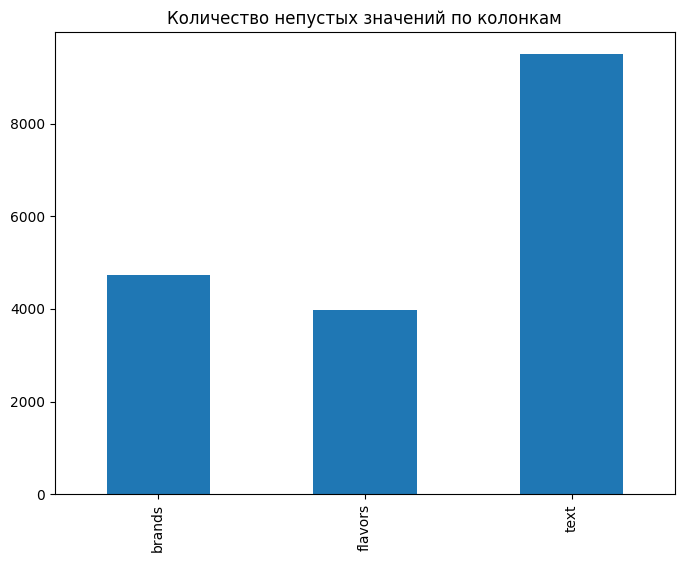

In [439]:
# статистика по найденным полям
import matplotlib.pyplot as plt
data_with_query.drop(columns=['characteristics']).notna().sum().plot(kind='bar', figsize=(8,6), title='Количество непустых значений по колонкам')
plt.show()

Тут просто о том, что мы бренд каким-то образом определили примерно в половине примеров, вкус еще в чуть меньше половины.

In [448]:
all_brands = data_with_query["brands"].dropna().tolist()
all_flavors = data_with_query["flavors"].dropna().tolist()
all_other = data_with_query["characteristics"].dropna().tolist()

## БРЕНДЫ

In [394]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

def generate_wordcloud(text, max_words=100, width=800, height=600):
    # Разбиваем текст на слова и подсчитываем частоту
    words = text.split(", ")
    word_freq = Counter(words)
    
    # Создаем облако слов
    wordcloud = WordCloud(
        width=width,
        height=height,
        background_color='white',
        max_words=max_words,
        colormap='viridis'
    ).generate_from_frequencies(word_freq)
    
    # Отображаем облако
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [383]:
brand_variants = {
    "Barilla": ["барилла", "бариила", "бариллп", "барила", "барил", "Barilla"],
    "Coca-Cola": ["кока-кола", "Кока-Кола", "кока кола", "Кока Кола", "Coca-Cola", "Coca Cola", "coolcola", "Кока-Кола", "Кока Кола", "кола"],
    "Nestle": ["Nestle", "Нестле", "Nestogen"],
    "Kit Kat": ["Kit Kat", "Кит Кат", "kıktat", "китткет", "Kitkat", "китекеи"],
    "M&M's": ["M&Ms", "m m s", "емэмдэмс", "MMS", "M&", "m&m's", "M&M"],
    "Snickers": ["Snickers", "сникерс", "сникер"],
    "Red Bull": ["Red Bull", "редбул", "Редбул", "редб Bull"],
    "Pringles": ["Pringles", "прингз", "прингл", "принглс"],
    "Lay's": ["Lay's", "Lays", "лейс", "lay"],
    "Oreo": ["Oreo", "Орео"],
    "Twix": ["Twix", "Твикс"],
    "Milka": ["Milka", "Милка"],
    "Alpen Gold": ["Alpen Gold", "Алпен Голд", "албпен"],
    "Ritter Sport": ["Ritter Sport", "Риттер спорт", "риттер спорт", "Ritter"],
    "Kinder": ["Kinder", "Киндер", "Kinders", "киндер", "Kinder Bueno", "кинд"],
    "Nutella": ["Nutella", "Нутелла", "нутелк"],
    "Ferrero Rocher": ["Ferrero Rocher", "Ферреро Роше", "ферро роше"],
    "Raffaello": ["Raffaello", "Рафаэлло", "рафа"],
    "Mars": ["Mars", "Марс"],
    "Pepsi": ["Пепси"],
    "Fanta": ["Фанта"],
    "Sprite": ["Спрайт"],
    "Mountain Dew": ["Маунти Дью"],
    "Evervess": ["Evervess", "Евервейс"],
    "Nesquik": ["Nesquik", "Несквик"],
    "Nestea": ["Nestea"],
    "Lipton": ["Lipton", "Липтон", "Липтей", "Липтоман"],
    "Greenfield": ["Greenfield", "Greengield"],
    "Ahmad Tea": ["Ahmad", "Ахмад"],
    "Basilur": ["Basilur"],
    "Lavazza": ["Лаваццо"],
    "Nescafé": ["Nescafé"],
    "Starbucks": ["Starbucks"],
    "McDonald's": ["Макдональдс"],
    "KFC": ["КФС", "KFC"],
    "Rostik's": ["Ростикс"],
    "Пятерочка": ["Пятерочка"],
    "Мираторг": ["Мираторг", "Миротрог", "Мирторг"],
    "Черкизово": ["Черкизово"],
    "Петелинка": ["Петелинка", "петельнка", "Петелинка Премиум"],
    "Простоквашино": ["Простоквашино", "простокыа"],
    "Агуша": ["Агуша"],
    "ФрутоНяня": ["Фрутоняня", "фрутонян"],
    "Nutrilon": ["Nutrilon", "Нутрилон", "Нутрилак"],
    "Nestogen": ["Nestogen"],
    "Similac": ["Similac"],
    "Hipp": ["Hipp"],
    "Bonduelle": ["Bonduelle"],
    "Heinz": ["Heinz", "Хайнц"],
    "Kraft": ["Kraft", "Крафт"],
    "Maggi": ["Maggi", "Магги"],
    "Knorr": ["Knorr", "Кнорр"],
    "Rollton": ["Rollton", "Ролтон", "роллтон"],
    "Доширак": ["Доширак", "доши"],
    "Мивина": ["Мивина"],
    "Кириешки": ["Кириешки", "кирьеш"],
    "Cheetos": ["Cheetos", "читос"],
    "Cif": ["Cif"],
    "Domestos": ["Доместос"],
    "Fairy": ["Fairy", "Фери"],
    "Tide": ["Tide"],
    "Ariel": ["Ariel", "Ариель"],
    "Lenor": ["Lenor"],
    "Persil": ["Персил"],
    "Rexona": ["Rexona"],
    "Old Spice": ["Old Spice", "Олдспай"],
    "Nivea": ["Нивеа"],
    "Garnier": ["Garnier"],
    "L'Oréal": ["L'Oréal", "Лореал", "L'oreal", "l'oreal"],
    "La Roche-Posay": ["La Roche-Posay", "Ла роше", "Roche"],
    "Clinique": ["Clinique"],
    "Lancôme": ["Lancôme", "Lancome"],
    "YSL": ["YSL"],
    "Calvin Klein": ["Calvin Klein", "Calvin"],
    "Dolce & Gabbana": ["Dolce & Gabbana", "Gabbana"],
    "Giorgio Armani": ["Armani"],
    "Tommy Hilfiger": ["Tommy"],
    "Tom Ford": ["Tom Ford"],
    "Hugo Boss": ["Boss"],
    "Adidas": ["Адидас"],
    "Nike": ["Nike"],
    "Samsung": ["Samsung", "Сэмсонг"],
    "Huawei": ["Huawei"],
    "Apple": ["Apple", "iPhone", "AirPods", "айфон", "аиподс"],
    "PlayStation": ["PlayStation"],
    "LEGO": ["LEGO"],
    "Maxxis": ["Maxxis"],
    "Pampers": ["Pampers", "Памперсы", "памперs"],
    "Huggies": ["Huggies"],
    "Merries": ["Merries", "Merri"],
    "Naturella": ["Naturella"],
    "Kotex": ["Kotex"],
    "Libresse": ["Libresse"],
    "Always": ["Always"],
    "Sheba": ["Sheba"],
    "Whiskas": ["Whiskas", "Вискас"],
    "Purina": ["Purina", "Purina One", "Pro Plan", "Пурина"],
    "Royal Canin": ["Royal Canin", "Royal Conin"],
    "Iams": ["Iams"],
    "Felix": ["Felix"],
    "Kitekat": ["Kitekat", "китекеи"],
    "Pedigree": ["Pedigree", "Педигри"],
    "Baskin Robbins": ["Baskin Robbins", "Баскин"],
    "Chupa Chups": ["Chupa Chups", "Чупа Чупс", "чупачупс", "чупа чупс", "Чупа", "Chupa", "чупасупч", "чупачвпс", "чупачёррио", "чупачук", "чупа ч2пс"],
    "Skittles": ["Skittles", "скитлз", "скитл"],
    "Mentos": ["Mentos", "Ментос"],
    "Tic Tac": ["Tic tac"],
    "Strepsils": ["Стрепсил", "стрепсилс"],
    "Nurofen": ["Нурофен", "Nurofen"],
    "Ессентуки": ["Ессентуки", "Есентуки", "Йесентук", "Эсенте"],
    "Боржоми": ["Боржоми", "Боржо"],
    "Нарзан": ["Нарзан"],
    "Карачинская": ["Карачинская"],
    "Черноголовка": ["Черноголовка", "черноголовак"],
    "Архыз": ["Архыз"],
    "Святой источник": ["Святой источник"],
    "Абрау-Дюрсо": ["Абрау", "Абрау Дюрсо"],
    "Балтика": ["Балтика"],
    "Stella Artois": ["Stella Artois", "Стелла артуа"],
    "Guinness": ["Guinness"],
    "Martini": ["Martini"],
    "Gin Mare": ["Gin Mare"],
    "Schweppes": ["Швепс", "schwepes"],
    "Juul": ["juul"],
    "Heets": ["Heets"],
    "IQOS": ["айкос"],
    "Honor": ["Honor"],
    "Geox": ["Geox"],
    "Levi's": ["Levi", "Levis"],
    "Macy's": ["Macy's"],
    "Zara": ["Zara"],
    "H&M": ["H&M", "h m", "H M"],
    "Hermès": ["Хермес", "Hermes"],
    "Cartier": ["Cartie"],
    "Marc Jacobs": ["Марк якобс"],
    "Byredo": ["Byredo"],
    "Jo Malone": ["Jo Malone"],
    "Etude House": ["Etude"],
    "Kerasys": ["Kerasys"],
    "Sensai": ["Sensai"],
    "Batiste": ["Batiste"],
    "Carmex": ["Carmex"],
    "Avizor": ["Avizor"],
    "Splat": ["Splat"],
    "Celimax": ["Celimax"],
    "Mixit": ["Mixit"],
    "Eveline Cosmetics": ["Eveline cosmetics"],
    "Unleashia": ["Unleashia"],
    "Huda Beauty": ["Huda"],
    "Bobbi Brown": ["Bobbi"],
    "Gillette": ["Gillette"],
    "Harry's": ["Harry's"],
    "Bic": ["Bic"],
    "Bombbar": ["Bombbar"],
    "MaxFuel": ["MaxFuel"],
    "GoodMix": ["GoodMix", "Goodmix"],
    "Bionova": ["Bionova"],
    "Nutri-Grain": ["Nutri-Grain"],
    "Choco Pie": ["Choco Pie", "чоко пай"],
    "Cornetto": ["Cornetto"],
    "Orion": ["Orion"],
    "Lotte": ["Lotte"],
    "Lindt": ["Lindt"],
    "Merci": ["Мерси"],
    "Pabst Blue Ribbon": ["Pabst Blue Ribbon"],
    "Exponenta": ["Exponenta", "экспонента"],
    "Organica": ["Organica"],
    "Prosept": ["Prosept"],
    "Green Smith": ["Green Smith"],
    "Sveza": ["Sveza"],
    "Zewa": ["Zewa"],
    "Paclan": ["Paclan"],
    "Duluth": ["Duluth"],
    "Himalaya Herbals": ["Himalaya Herbals"],
    "Arko": ["Arko"],
    "Hero": ["Hero"],
    "Pure": ["Pure"],
    "Cesar": ["Cesar"],
    "Mira": ["Mira"],
    "Mika": ["Mika"],
    "Bella": ["Белла", "Bella"],
    "Самокат": ["самокат"],
    "Немолоко": ["немолоко"]
}

variant_to_brand = {}
for brand, variants in brand_variants.items():
    for v in variants:
        # Приводим вариант к нижнему регистру для регистронезависимого поиска
        variant_to_brand[v.lower()] = brand

print(variant_to_brand)

{'барилла': 'Barilla', 'бариила': 'Barilla', 'бариллп': 'Barilla', 'барила': 'Barilla', 'барил': 'Barilla', 'barilla': 'Barilla', 'кока-кола': 'Coca-Cola', 'кока кола': 'Coca-Cola', 'coca-cola': 'Coca-Cola', 'coca cola': 'Coca-Cola', 'coolcola': 'Coca-Cola', 'кола': 'Coca-Cola', 'nestle': 'Nestle', 'нестле': 'Nestle', 'nestogen': 'Nestogen', 'kit kat': 'Kit Kat', 'кит кат': 'Kit Kat', 'kıktat': 'Kit Kat', 'китткет': 'Kit Kat', 'kitkat': 'Kit Kat', 'китекеи': 'Kitekat', 'm&ms': "M&M's", 'm m s': "M&M's", 'емэмдэмс': "M&M's", 'mms': "M&M's", 'm&': "M&M's", "m&m's": "M&M's", 'm&m': "M&M's", 'snickers': 'Snickers', 'сникерс': 'Snickers', 'сникер': 'Snickers', 'red bull': 'Red Bull', 'редбул': 'Red Bull', 'редб bull': 'Red Bull', 'pringles': 'Pringles', 'прингз': 'Pringles', 'прингл': 'Pringles', 'принглс': 'Pringles', "lay's": "Lay's", 'lays': "Lay's", 'лейс': "Lay's", 'lay': "Lay's", 'oreo': 'Oreo', 'орео': 'Oreo', 'twix': 'Twix', 'твикс': 'Twix', 'milka': 'Milka', 'милка': 'Milka', 'alpe

In [382]:
brands_clean = []

for brand in all_brands:
    if brand in variant_to_brand.keys():
        brands_clean.append(variant_to_brand[brand])

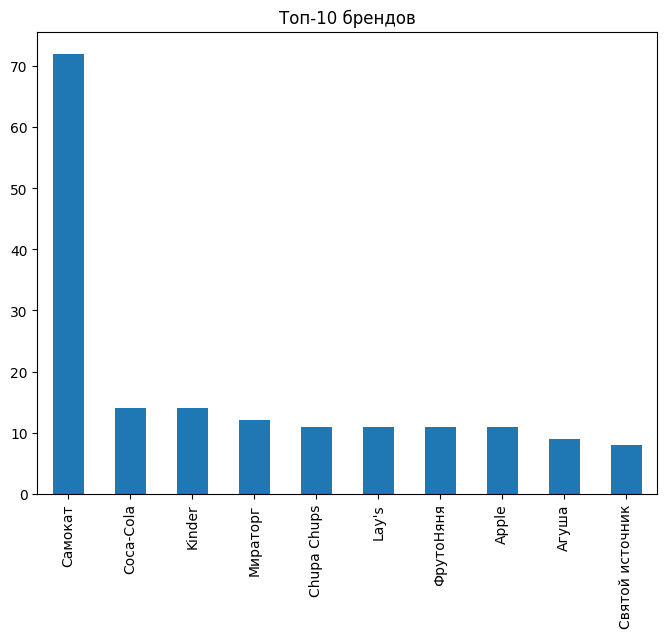

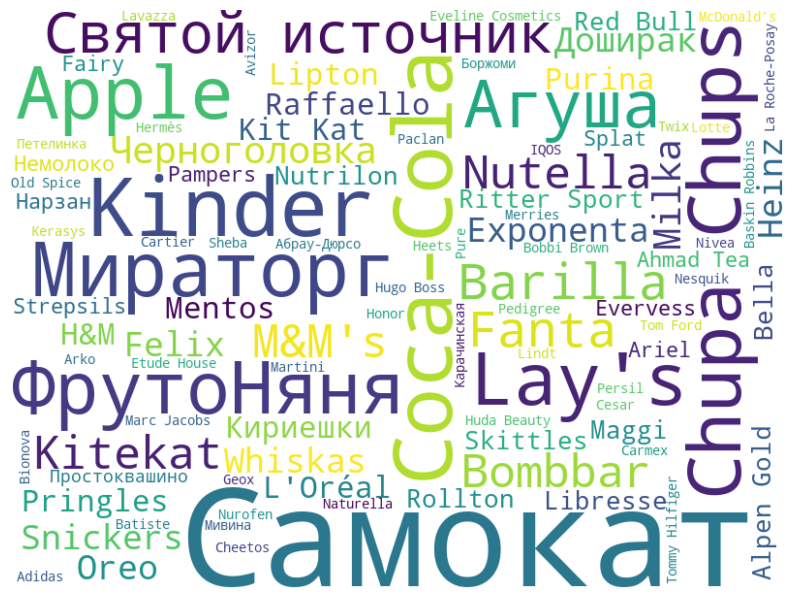

In [385]:
word_freq_brands = Counter(brands_clean)
pd.Series(Counter(brands_clean)).sort_values(ascending=False).head(10).plot(kind='bar', figsize=(8,6), title='Топ-10 брендов')
plt.show()
generate_wordcloud(', '.join(brands_clean))

## ВКУСЫ

In [452]:
flavor_mapping = {
    # Шоколад
    'шоколад': 'шоколадный',
    'шоколадный': 'шоколадный',
    'шоковый': 'шоколадный',
    'чоколадный': 'шоколадный',
    'чоко': 'шоколадный',
    'шок': 'шоколадный',
    'chocolate': 'шоколадный',
    'choco': 'шоколадный',
    
    # Сыр
    'сыр': 'сырный',
    'сырный': 'сырный',
    'сырок': 'сырный',
    'сырища': 'сырный',
    'cheese': 'сырный',
    'сир': 'сырный',
    
    # Творог
    'творог': 'творожный',
    'творожный': 'творожный',
    'твор': 'творожный',
    'творр': 'творожный',
    
    # Сливочный
    'сливка': 'сливочный',
    'сливочный': 'сливочный',
    'сливковый': 'сливочный',
    'слив': 'сливочный',
    'сметана': 'сливочный',
    'cream': 'сливочный',
    'creamy': 'сливочный',
    
    # Клубника
    'клубника': 'клубничный',
    'клубничный': 'клубничный',
    'клуб': 'клубничный',
    
    # Малина
    'малина': 'малиновый',
    'малинный': 'малиновый',
    'малиновый': 'малиновый',
    
    # Яблоко
    'яблоко': 'яблочный',
    'яблочный': 'яблочный',
    'apple': 'яблочный',
    
    # Апельсин
    'апельсин': 'апельсиновый',
    'апельсиновый': 'апельсиновый',
    'orange': 'апельсиновый',
    
    # Лимон
    'лимон': 'лимонный',
    'лимонный': 'лимонный',
    'lemon': 'лимонный',
    'lime': 'лаймовый',
    'лаймовый': 'лаймовый',
    
    # Банан
    'банан': 'банановый',
    'банановый': 'банановый',
    'banana': 'банановый',
    
    # Ананас
    'ананас': 'ананасовый',
    'ананасовый': 'ананасовый',
    'pineapple': 'ананасовый',
    
    # Персик
    'персик': 'персиковый',
    'персиковый': 'персиковый',
    'peach': 'персиковый',
    
    # Вишня
    'вишня': 'вишнёвый',
    'вишнёвый': 'вишнёвый',
    'вишень': 'вишнёвый',
    'черри': 'вишнёвый',
    'cherry': 'вишнёвый',
    
    # Манго
    'манго': 'манговый',
    'манго': 'манговый',
    'mango': 'манговый',
    
    # Кокос
    'кокос': 'кокосовый',
    'кокосовый': 'кокосовый',
    'coconut': 'кокосовый',
    
    # Кофе
    'кофе': 'кофейный',
    'кофейный': 'кофейный',
    'coffee': 'кофейный',
    
    # Молоко
    'молоко': 'молочный',
    'молочный': 'молочный',
    'milk': 'молочный',
    'milky': 'молочный',
    
    # Ваниль
    'ваниль': 'ванильный',
    'ванильный': 'ванильный',
    'vanilla': 'ванильный',
    'vanil': 'ванильный',
    'ванilia': 'ванильный',
    
    # Мята
    'мята': 'мятный',
    'мятный': 'мятный',
    'mint': 'мятный',
    
    # Карамель
    'карамель': 'карамельный',
    'карамельный': 'карамельный',
    'caramel': 'карамельный',
    
    # Орех
    'орех': 'ореховый',
    'ореховый': 'ореховый',
    'орешный': 'ореховый',
    'орешной': 'ореховый',
    'nut': 'ореховый',
    
    # Миндаль
    'миндаль': 'миндальный',
    'миндальный': 'миндальный',
    'almond': 'миндальный',
    
    # Фисташка
    'фисташка': 'фисташковый',
    'фисташковый': 'фисташковый',
    'фистачьо': 'фисташковый',
    
    # Арахис
    'арахис': 'арахисовый',
    'арахисовый': 'арахисовый',
    'peanut': 'арахисовый',
    
    # Курица
    'курица': 'куриный',
    'куриный': 'куриный',
    'куринный': 'куриный',
    'chicken': 'куриный',
    
    # Говядина
    'говядина': 'говяжий',
    'говяжий': 'говяжий',
    'beef': 'говяжий',
    
    # Рыба
    'рыба': 'рыбный',
    'рыбный': 'рыбный',
    'fish': 'рыбный',
    
    # Мясо
    'мясо': 'мясной',
    'мясной': 'мясной',
    'meat': 'мясной',
    
    # Грибы
    'гриб': 'грибной',
    'грибной': 'грибной',
    'mushroom': 'грибной',
    
    # Томат
    'томат': 'томатный',
    'томатный': 'томатный',
    'помидор': 'помидорный',
    'помидорный': 'помидорный',
    'tomato': 'томатный',
    
    # Огурец
    'огурец': 'огурцовый',
    'огурцовый': 'огурцовый',
    'cucumber': 'огурцовый',
    
    # Лук
    'лук': 'луковый',
    'луковый': 'луковый',
    'onion': 'луковый',
    
    # Чеснок
    'чеснок': 'чесночный',
    'чесночный': 'чесночный',
    'garlic': 'чесночный',
    
    # Перец
    'перец': 'перечный',
    'перечный': 'перечный',
    'pepper': 'перечный',
    'chili': 'чили',
    'чили': 'чили',
    'халапеньо': 'халапеньо',
    
    # Морковь
    'морковь': 'морковный',
    'морковный': 'морковный',
    'carrot': 'морковный',
    
    # Картофель
    'картофель': 'картофельный',
    'картофельный': 'картофельный',
    'potato': 'картофельный',
    
    # Рис
    'рис': 'рисовый',
    'рисовый': 'рисовый',
    'rice': 'рисовый',
    
    # Злаки
    'злак': 'злаковый',
    'злаковый': 'злаковый',
    'grain': 'злаковый',
    'зерновой': 'зерновой',
    'зерно': 'зерновой',
    
    # Овёс
    'овёс': 'овсяный',
    'овсяный': 'овсяный',
    'oat': 'овсяный',
    
    # Пшеница
    'пшеница': 'пшеничный',
    'пшеничный': 'пшеничный',
    'wheat': 'пшеничный',
    
    # Сладкий
    'сладкий': 'сладкий',
    'сладкое': 'сладкий',
    'sweet': 'сладкий',
    
    # Солёный
    'солёный': 'солёный',
    'соленый': 'солёный',
    'salt': 'солёный',
    
    # Кислый
    'кислый': 'кислый',
    'sour': 'кислый',
    
    # Острый
    'острый': 'острый',
    'spicy': 'острый',
    
    # Копчёный
    'копчёный': 'копчёный',
    'копченый': 'копчёный',
    'smoked': 'копчёный',
    
    # Варёный
    'варёный': 'варёный',
    'вареный': 'варёный',
    'cooked': 'варёный',
    
    # Мороженое
    'мороженое': 'мороженое',
    'морженой': 'мороженое',
    'мороженный': 'мороженое',
    'ice cream': 'мороженое',
    
    # Йогурт
    'йогурт': 'йогуртовый',
    'йогуртовый': 'йогуртовый',
    'yogurt': 'йогуртовый',
    
    # Десерт
    'десерт': 'десертный',
    'десертный': 'десертный',
    'dessert': 'десертный',
    
    # Пирожное
    'пирожное': 'пирожное',
    'торт': 'торт',
    
    # Печенье
    'печенье': 'печенье',
    'печение': 'печенье',
    'cookie': 'печенье',
    
    # Вафля
    'вафля': 'вафельный',
    'вафельный': 'вафельный',
    'waffle': 'вафельный',
    
    # Мороженое
    'пломбир': 'пломбирный',
    'пломбирный': 'пломбирный',
    'plombir': 'пломбирный',
    
    # Колбаса
    'колбаса': 'колбасный',
    'колбасный': 'колбасный',
    'sausage': 'колбасный',
    
    # Ветчина
    'ветчина': 'ветчиный',
    'ветчиный': 'ветчиный',
    'ham': 'ветчиный',
    
    # Бекон
    'бекон': 'беконовый',
    'беконовый': 'беконовый',
    'bacon': 'беконовый',
    
    # Морепродукты
    'морепродукт': 'морской',
    'морской': 'морской',
    'seafood': 'морской',
    
    # Креветка
    'креветка': 'креветковый',
    'креветковый': 'креветковый',
    'shrimp': 'креветковый',
    
    # Краб
    'краб': 'крабовый',
    'крабовый': 'крабовый',
    'crab': 'крабовый',
    
    # Лосось
    'лосось': 'лососёвый',
    'лососёвый': 'лососёвый',
    'salmon': 'лососёвый',
    
    # Форель
    'форель': 'форелевый',
    'trout': 'форелевый',
    
    # Тунец
    'тунец': 'тунцовый',
    'tuna': 'тунцовый',
    
    # Сельдь
    'сельдь': 'сельдевый',
    'селёдка': 'сельдевый',
    'herring': 'сельдевый',
    
    # Ягоды
    'ягода': 'ягодный',
    'ягодный': 'ягодный',
    'berry': 'ягодный',
    
    # Фрукты
    'фрукт': 'фруктовый',
    'фруктовый': 'фруктовый',
    'fruit': 'фруктовый',
    
    # Цитрус
    'цитрус': 'цитрусовый',
    'цитрусовый': 'цитрусовый',
    'citrus': 'цитрусовый',
    
    # Гранат
    'гранат': 'гранатовый',
    'гранатовый': 'гранатовый',
    'pomegranate': 'гранатовый',
    
    # Виноград
    'виноград': 'виноградный',
    'виноградный': 'виноградный',
    'grape': 'виноградный',
    
    # Арбуз
    'арбуз': 'арбузный',
    'watermelon': 'арбузный',
    
    # Дыня
    'дыня': 'дынный',
    'дынный': 'дынный',
    'melon': 'дынный',
    
    # Специи
    'специя': 'пряный',
    'пряный': 'пряный',
    'spice': 'пряный',
    
    # Корица
    'корица': 'коричный',
    'коричный': 'коричный',
    'cinnamon': 'коричный',
    
    # Имбирь
    'имбирь': 'имбирный',
    'имбирный': 'имбирный',
    'ginger': 'имбирный',
    
    # Васаби
    'васаби': 'васаби',
    'wasabi': 'васаби',
    
    # Горчица
    'горчица': 'горчичный',
    'горчичный': 'горчичный',
    'mustard': 'горчичный',
    
    # Майонез
    'майонез': 'майонезный',
    'майонезный': 'майонезный',
    'mayo': 'майонезный',
    
    # Кетчуп
    'кетчуп': 'кетчупный',
    'ketchup': 'кетчупный',
    
    # Соус
    'соус': 'соусный',
    'sauce': 'соусный',
    
    # Барбекю
    'барбекю': 'барбекю',
    'bbq': 'барбекю',
    'barbecue': 'барбекю',
    
    # Салат
    'салат': 'салатный',
    'салатный': 'салатный',
    'salad': 'салатный',
    
    # Пицца
    'пицца': 'пицца',
    'pizza': 'пицца',
    
    # Хлеб
    'хлеб': 'хлебный',
    'хлебный': 'хлебный',
    'bread': 'хлебный',
    
    # Булочка
    'булка': 'булочный',
    'булочный': 'булочный',
    'bun': 'булочный',
    
    # Макароны
    'макароны': 'макаронный',
    'макаронный': 'макаронный',
    'pasta': 'макаронный',
    
    # Суп
    'суп': 'суповой',
    'soup': 'суповой',
    
    # Бульон
    'бульон': 'бульонный',
    'бульонный': 'бульонный',
    'broth': 'бульонный',
    
    # Каша
    'каша': 'каша',
    'porridge': 'каша',
    
    # Энергетик
    'энергетик': 'энергетический',
    'энергетический': 'энергетический',
    'energy': 'энергетический',
    'energetic': 'энергетический',
    
    # Детский
    'детский': 'детский',
    'baby': 'детский',
    'kids': 'детский',
    'для детей': 'детский',
    
    # Минеральный
    'минеральный': 'минеральный',
    'минералка': 'минеральный',
    'mineral': 'минеральный',
    
    # Газированный
    'газировка': 'газированный',
    'газировать': 'газированный',
    'газированный': 'газированный',
    'soda': 'газированный',
    'carbonated': 'газированный',
    
    # Без сахара
    'без сахара': 'без сахара',
    'sugar free': 'без сахара',
    'sugarfree': 'без сахара',
    
    # Без лактозы
    'без лактоза': 'безлактозный',
    'безлактозный': 'безлактозный',
    'безлак': 'безлактозный',
    'lactose free': 'безлактозный',
    
    # Протеиновый
    'протеин': 'протеиновый',
    'протеиновый': 'протеиновый',
    'protein': 'протеиновый',
    
    # Растительный
    'растительный': 'растительный',
    'plant': 'растительный',
    'vegan': 'растительный',
    
    # Тертый
    'тёртый': 'тёртый',
    'тертый': 'тёртый',
    'grated': 'тёртый',
    
    # Плавленый
    'плавленый': 'плавленый',
    'processed': 'плавленый',
    
    # Сухой
    'сухой': 'сухой',
    'dry': 'сухой',
    'dried': 'сухой',
    
    # Влажный
    'влажный': 'влажный',
    'wet': 'влажный',
    'moist': 'влажный',
    
    # Свежий
    'свежий': 'свежий',
    'fresh': 'свежий',
    
    # Горячий
    'горячий': 'горячий',
    'hot': 'горячий',
    
    # Холодный
    'холодный': 'холодный',
    'cold': 'холодный',
    
    # Лесной
    'лесной': 'лесной',
    'forest': 'лесной',
    
    # Цветочный
    'цветочный': 'цветочный',
    'floral': 'цветочный',
    
    # Древесный
    'древесный': 'древесный',
    'woody': 'древесный',
    
    # Табачный
    'табачный': 'табачный',
    'tobacco': 'табачный'
}

def normalize_flavor(word):
    """Нормализует вкус с использованием маппинга"""
    if not isinstance(word, str):
        return word
    word_lower = word.lower().strip()
    
    # Проверяем точное совпадение
    if word_lower in flavor_mapping:
        return flavor_mapping[word_lower]
    
    # Проверяем по префиксам (для быстрой группировки)
    for key, value in flavor_mapping.items():
        if word_lower.startswith(key) or key.startswith(word_lower):
            return value
    
    # Если ничего не найдено, возвращаем как есть
    return word_lower

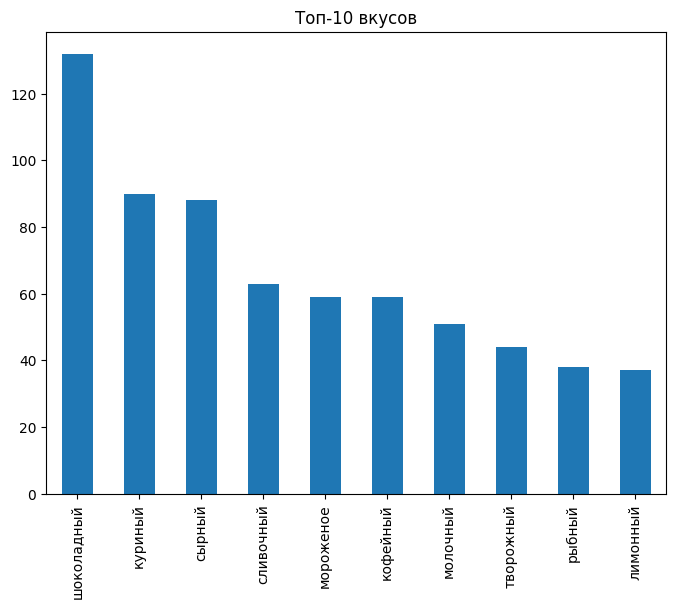

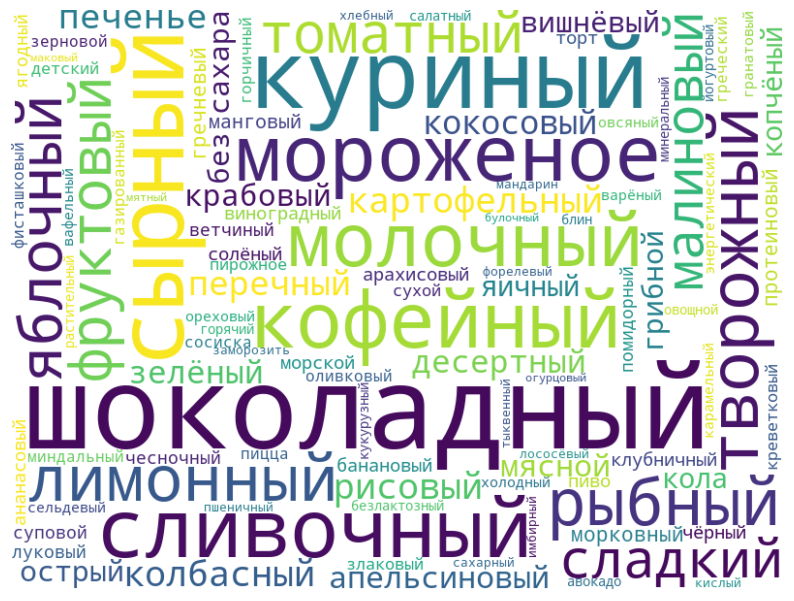

In [453]:
import pymorphy3
import re
import pandas as pd
import matplotlib.pyplot as plt

morph = pymorphy3.MorphAnalyzer()

def normalize(word):
    try:
        return morph.parse(word)[0].normal_form
    except:
        return word

# Нормализуем и группируем
normalized_flavors = [normalize_flavor(normalize(w)) for w in all_flavors if isinstance(w, str)]

# Правильно считаем частоты слов
word_freq_flavors = Counter(normalized_flavors)

# Визуализация
pd.Series(word_freq_flavors).sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(8,6), title='Топ-10 вкусов'
)
plt.show()

# Облако слов
generate_wordcloud(', '.join(normalized_flavors))

In [451]:
print(normalized_flavors)

['творожный', 'шоколадный', 'попкорн', 'шоколадный', 'корм для котёнок', 'сыр', 'шпинатный', 'готовая ед', 'сливочный', 'пузырчатая плёнка', 'тушёный', 'сгущённая малак', 'розовый, голубой', 'кола', 'кислый', 'форель', 'помидорный', 'тёртый', 'панировочный', 'креветковый', 'куриный', 'вкусный', 'злаковый', 'корица', 'нв', 'ароматический', 'мармелад', 'творожный', 'черь', 'югорт', 'желтковый', 'из фрукт', 'сырокопчёный', 'персиковый', 'майонезный', 'с шпин', 'без специя', 'вкусный', 'тушёнка', 'плавить', '608', 'клубничный', 'детский', 'сырный, масляный', 'морженой', 'копчёный', 'коokies', 'пицца', 'слоеное, дрожжевой', 'индейский', 'момент пряности, момент солода, момент карамеля', 'пшеничный', 'манго', 'сало', 'молочный, кофе', 'ананас', 'огурец, помидор', 'апельсиновый', 'шоковый', 'икрв', 'луковый', 'лимонад', 'халапеньо', 'стиковый', 'светлый', 'веgetables for borscht', 'каша', 'сыр', 'нутта', 'пиво', 'много белка', 'для рука', 'жасминный', 'мороженое, эскимо', 'whiskey', 'шоколад'